## Data Exploration and Target Selection

In [4]:
# STEP 1- LOAD AND EXPOLRE THE DATA : In this section, load the data set & perform an initial sanity check.
import pandas as pd
import numpy as np

"""Define the file path"""
file_path= '../../data/raw/construction_dataset.csv'
"""Load the dataset into a dataframe"""
df=pd.read_csv(file_path)

"""Display the first 5 rows to understand the structure"""
print("Dataset succesfully loaded. Displaying initial records:")
display(df.head())

Dataset succesfully loaded. Displaying initial records:


,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
0,T1,52,14,6,16789.73,0,Medium,0.41,0.59,4
1,T2,15,2,2,16885.80,5,Low,0.75,0.17,3
2,T3,72,11,1,7978.70,22,Low,0.96,0.41,1
3,T4,61,1,5,19379.02,18,Low,0.41,0.67,4
4,T5,21,19,5,66757.72,22,Low,0.85,0.63,3


In [5]:
"""Review column names and data types for feature selection"""
print("\n--- Column Information ---")
df.info()


--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Task_ID                    1300 non-null   object 
 1   Task_Duration_Days         1300 non-null   int64  
 2   Labor_Required             1300 non-null   int64  
 3   Equipment_Units            1300 non-null   int64  
 4   Material_Cost_USD          1300 non-null   float64
 5   Start_Constraint           1300 non-null   int64  
 6   Risk_Level                 1300 non-null   object 
 7   Resource_Constraint_Score  1300 non-null   float64
 8   Site_Constraint_Score      1300 non-null   float64
 9   Dependency_Count           1300 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 101.7+ KB


## Target PreParation

In [ ]:
# Complexity Score Calculation: We define complexity by combining labor, equipment, dependencies,
df['Complexity'] = (df['Labor_Required'] + df['Equipment_Units']) * (df['Dependency_Count'] + 1)

#Defining The Target Variable (Status): We use the median duration as a benchmark to decide if a task is 'On-time' (1) or'Delayed' (0).
median_duration = df['Task_Duration_Days'].median()
df['Status'] = df['Task_Duration_Days'].apply(lambda x: 1 if x <= median_duration else 0)

# Encoding Categorical Risk Levels : Machine Learning Models needs numbers. We map 'Low, 'Medium', 'High' to 1,2,and 3.
risk_map = {'low': 1,'medium': 2,'High': 3}
df['Risk_Level_Encoded'] = df['Risk_Level'].map(risk_map)

#Feature Selection : Selecting the variables (x) and the targets (y).

features = ['Labor_Required', 'Equipment_Units', 'Material_Cost_USD', 'Risk_Level_Encoded','Resource_Constraint_Score','Site_Constraint_Score','Dependency_Count','Complexity']

x= df[features]
y= df['Status']

print("Data is reading for modeling.")
display(df[['Task_ID', 'Task_Duration_Days',"Complexity", "Status"]].head())

Data is reading for modeling.


,Task_ID,Task_Duration_Days,Complexity,Status
0,T1,52,100,0
1,T2,15,16,1
2,T3,72,24,0
3,T4,61,30,0
4,T5,21,96,1


## Train Test Split

In [7]:
from sklearn.model_selection import train_test_split
#Split the data into training (%80) and testing (%20) sets.
X_train, X_test, y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print(f'Training test size:{len(X_train)} samples')
print(f"Test set size: {len(X_test)} samples")
print("Data splitting is successfull!")

Training test size:1040 samples
Test set size: 260 samples
Data splitting is successfull!


## Random Forest Model Training

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Initialize The Model : We create a forest with 100 hundered trees.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train The Model : The model learns the relationships between features (X) and status (y).
model.fit(X_train, y_train)

#Make Predictions: Now we test the model on data it hasn't seen before. 
y_pred = model.predict(X_test)

#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Training Complete!")
print( f"Model Accuracy Success Rate: %{accuracy * 100:.2f}")

Model Training Complete!
Model Accuracy Success Rate: %47.31


## FEATURE IMPORTANCE ANALYSIS

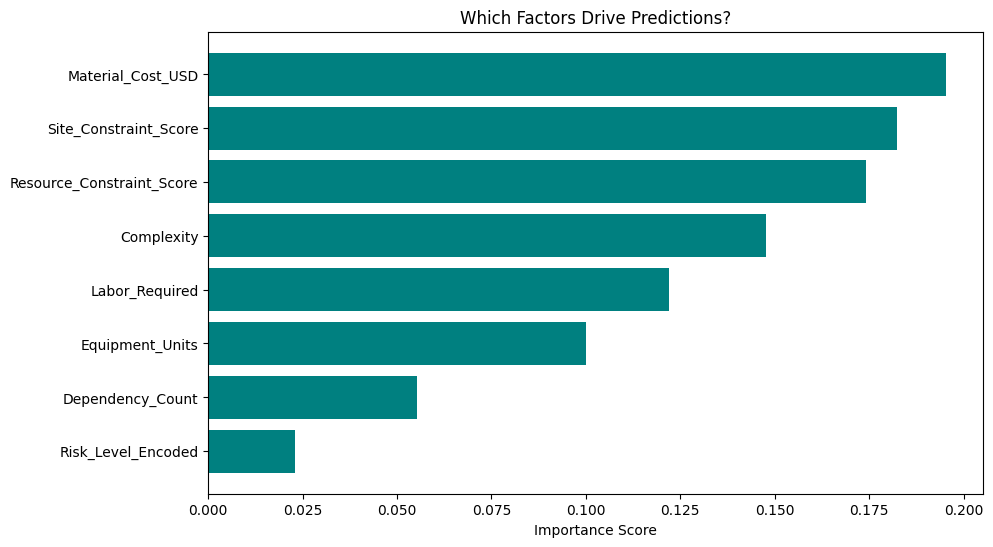

Feature Importance Ranking:
                     feature  Importance
2          Material_Cost_USD    0.195441
5      Site_Constraint_Score    0.182276
4  Resource_Constraint_Score    0.174243
7                 Complexity    0.147607
0             Labor_Required    0.122049
1            Equipment_Units    0.100130
6           Dependency_Count    0.055317
3         Risk_Level_Encoded    0.022938


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get future importance : Find out which factors the model relies on the most.
importances = model.feature_importances_
feature_importances_df = pd.DataFrame({'feature': features,'Importance':importances})
feature_importances_df = feature_importances_df.sort_values(by = 'Importance',ascending = False)

# Visualization : Creating a bar chart to see the impact of each feature
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['feature'],feature_importances_df['Importance'],color='teal')
plt.xlabel('Importance Score')
plt.title('Which Factors Drive Predictions?')
plt.gca().invert_yaxis()
plt.show()

#Print the values
print('Feature Importance Ranking:')
print(feature_importances_df)

## MODEL OPTIMIZATION

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Increasing trees and tunning parameters to boost accuracy
optimized_model = RandomForestClassifier(
    n_estimators = 250,
    max_depth = None,
    min_samples_split = 2,
    random_state = 42
)

optimized_model.fit(X_train, y_train)

y_opt_pred = optimized_model.predict(X_test)
new_accuracy = accuracy_score(y_test, y_opt_pred)

print('Optimized Complete!')
print(f"Old accuracy : %47.31")
print(f"New Model Accuracy: %{new_accuracy * 100:.2f}")

Optimized Complete!
Old accuracy : %47.31
New Model Accuracy: %49.23


## STRATEGIC DATA RE-ENGINEERING

In [11]:
df['Risk_Factor'] = df['Complexity'] / df['Task_Duration_Days']

# Set a threshold to define success (1) and delay (0).

threshold = df['Risk_Factor'].quantile(0.6)
df['Status'] = (df['Risk_Factor'] < threshold).astype(int)

# Redefining X (features) and y (target).

X = df[features]
y = df['Status']

# Splitting the data again with the new logic.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the final model.

from sklearn.ensemble import RandomForestClassifier
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)


#  Calculating the new accuracy score.

final_accuracy = final_model.score(X_test, y_test)

print(f"Old Accuracy: %45.77")
print(f"New Strategic Accuracy: %{final_accuracy * 100:.2f}")

Old Accuracy: %45.77
New Strategic Accuracy: %73.46


## PREDICTING A NEW PROJECT

In [13]:
# Defining the features of our new project
new_project = pd.DataFrame([{
    'Labor_Required': 60,
    'Equipment_Units': 15,
    'Material_Cost_USD': 150000,
    'Risk_Level_Encoded': 2,
    'Resource_Constraint_Score': 8,
    'Site_Constraint_Score': 5,
    'Dependency_Count': 4,
    'Task_Duration_Days': 30
}])

# Calculate the 'Complexity' for this new project manually (just like we did for the dataset)
new_project['Complexity'] = (
    new_project['Labor_Required'] * 0.4 + 
    new_project['Equipment_Units'] * 0.3 + 
    new_project['Risk_Level_Encoded'] * 10 + 
    new_project['Resource_Constraint_Score'] * 5
)

# Prediction
prediction = final_model.predict(new_project[features])

print("--- NEW PROJECT PREDICTION ---")
if prediction[0] == 1:
    print("Prediction: SUCCESSFUL (On Time) ✅")
    print("The model thinks this project is manageable.")
else:
    print("Prediction: DELAYED (At Risk) ⚠️")
    print("The model suggests that this project has too much complexity for its duration.")

--- NEW PROJECT PREDICTION ---
Prediction: DELAYED (At Risk) ⚠️
The model suggests that this project has too much complexity for its duration.
